<a href="https://colab.research.google.com/github/alecbidaran/Pytorch_excersies/blob/main/Actor_critic_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ptan
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install gym[atari]
!pip install pyvirtualdisplay
!pip install piglet
!pip install pytorch-ignite
!pip install gym[accept-rom-license]

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ptan: filename=ptan-0.4-py3-none-any.whl size=21525 sha256=523afeadb20487cc450c927a277aa5cf7e918521d3dd32927b406bdad27a2fce
  Stored in directory: /root/.cache/pip/wheels/e4/5e/4e/c5510a5109c2b45d74618730bb9615967d23c0f4a727507d6d
Successfully built ptan
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  freeglut3 libpython2-stdlib python2 python2-minimal
Suggested packages:
  python-tk python-numpy libgle3 python2-doc
The following NEW packages will be installed:
  freeglut3 libpython2-stdlib python-opengl python2 python2-minimal
0 upgraded, 5 newly installed, 0 to remove and 23 not upgraded.
Need to get 621 kB of archives.
After this operation, 6,0

In [ ]:
!apt-get install xdpyinfo

Reading package lists... Done
Building dependency tree       
Reading state information... Done
E: Unable to locate package xdpyinfo


In [ ]:
import gym
import collections
import ptan
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [ ]:
try:
    import pyvirtualdisplay
    display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
except ImportError:
    pass

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

make_env = lambda: ptan.common.wrappers.wrap_dqn(gym.make("PongNoFrameskip-v4"))
envs = [make_env() for _ in range(50)]
env=envs[0]

/usr/local/lib/python3.9/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.9/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
GAMMA = 0.99
LEARNING_RATE = 0.001
ENTROPY_BETA = 0.01
BATCH_SIZE = 128
NUM_ENVS = 50

REWARD_STEPS = 4
CLIP_GRAD = 0.1

In [ ]:
class AtariA2C(torch.nn.Module):
    def __init__(self, input_shape, n_actions):
        super(AtariA2C, self).__init__()

        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, kernel_size=4, stride=2),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 64, kernel_size=3, stride=1),
            torch.nn.ReLU()
        )

        conv_out_size = self._get_conv_out(input_shape)
        self.policy = torch.nn.Sequential(
            torch.nn.Linear(conv_out_size, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, n_actions)
        )

        self.value = torch.nn.Sequential(
            torch.nn.Linear(conv_out_size, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1)
        )

    def _get_conv_out(self, shape):
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        fx = x.float() / 256
        conv_out = self.conv(fx).view(fx.size()[0], -1)
        return self.policy(conv_out), self.value(conv_out)

In [ ]:
def unpack_batch(batch,device=device):
    states = []
    actions = []
    rewards = []
    not_done_idx = []
    last_states = []
    for idx,exp in enumerate(batch):
        state = np.array(exp.state)
        states.append(state)
        actions.append(exp.action)
        rewards.append(exp.reward)
        if exp.last_state is not None:
          not_done_idx.append(idx)
          lstate = np.array(exp.last_state,copy=False)
          last_states.append(lstate)
    states_v=torch.FloatTensor(np.array(states,copy=False)).to(device)
    action_t=torch.LongTensor(actions).to(device)
    rewards_np=np.array(rewards,copy=False)
    if not_done_idx:
      last_state_v=torch.FloatTensor(last_states).to(device)
      last_values=net(last_state_v)[1]
      last_values_np=last_values.detach().cpu().numpy()[:,0]
      last_values_np*=GAMMA**REWARD_STEPS
      rewards_np[not_done_idx]+=last_values_np
    ref_val_f=torch.FloatTensor(rewards_np).to(device)
    return states_v,action_t,ref_val_f



In [ ]:
net = AtariA2C(envs[0].observation_space.shape, envs[0].action_space.n).to(device)
print(net)

AtariA2C(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (policy): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
  (value): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=1, bias=True)
  )
)


In [ ]:
agent = ptan.agent.PolicyAgent(lambda x:net(x)[0]
                                   ,apply_softmax=True,device=device)
exp_source=ptan.experience.ExperienceSourceFirstLast(env,agent,gamma=GAMMA,steps_count=REWARD_STEPS)
optimizer = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)

In [ ]:
total_rewards = []
step_idx = 0
done_episodes = 0
plot_rewards=[]
batch = []
batch_episodes = 0
batch_states, batch_actions, batch_qvals = [], [], []
cur_states, cur_actions=[],[]
cur_rewards = []
for step_idx, exp in enumerate(exp_source):
      batch.append(exp)
        # handle new rewards
      new_rewards = exp_source.pop_total_rewards()
      if new_rewards:
            done_episodes += 1
            reward = new_rewards[0]
            total_rewards.append(reward)
            mean_rewards = float(np.mean(total_rewards[-100:]))
            print("%d: reward: %6.2f, mean_100: %6.2f, episodes: %d" % (
                step_idx, reward, mean_rewards, done_episodes))
            plot_rewards.append(mean_rewards)
            if mean_rewards >18:
                print("Solved in %d steps and %d episodes!" % (step_idx, done_episodes))
                break

      if len(batch) < BATCH_SIZE:
            continue
      states_v,action_t,ref_val=unpack_batch(batch,device=device)
      batch.clear()
      optimizer.zero_grad()
      pi,v=net(states_v)
      loss_value=F.mse_loss(v.squeeze(-1),ref_val)
      adv=ref_val-v.detach()
      log_val=F.log_softmax(pi,dim=-1)
      logits=adv*log_val[range(BATCH_SIZE),action_t]
      loss_policy=-logits.mean()
      loss_policy.backward(retain_graph=True)
      sm=F.softmax(pi,dim=-1)
      entropy=(sm*log_val)
      entropy_loss=ENTROPY_BETA*entropy.sum(dim=-1).mean()
      loss_v=loss_value+entropy_loss
      loss_v.backward()
      torch.nn.utils.clip_grad_norm_(net.parameters(),CLIP_GRAD)
      optimizer.step()
      loss_v+=loss_policy





553: reward: -16.00, mean_100: -16.00, episodes: 1
1403: reward: -21.00, mean_100: -18.50, episodes: 2
2189: reward: -21.00, mean_100: -19.33, episodes: 3
3163: reward: -19.00, mean_100: -19.25, episodes: 4
4236: reward: -20.00, mean_100: -19.40, episodes: 5
4993: reward: -21.00, mean_100: -19.67, episodes: 6
5749: reward: -21.00, mean_100: -19.86, episodes: 7
6510: reward: -21.00, mean_100: -20.00, episodes: 8
7298: reward: -21.00, mean_100: -20.11, episodes: 9
8074: reward: -21.00, mean_100: -20.20, episodes: 10
8943: reward: -20.00, mean_100: -20.18, episodes: 11
9705: reward: -21.00, mean_100: -20.25, episodes: 12
10462: reward: -21.00, mean_100: -20.31, episodes: 13
11221: reward: -21.00, mean_100: -20.36, episodes: 14
11977: reward: -21.00, mean_100: -20.40, episodes: 15
12736: reward: -21.00, mean_100: -20.44, episodes: 16
13497: reward: -21.00, mean_100: -20.47, episodes: 17
14431: reward: -20.00, mean_100: -20.44, episodes: 18
15216: reward: -21.00, mean_100: -20.47, episodes:

KeyboardInterrupt: ignored

## A2C for CARTPole

In [ ]:
env = gym.make("CartPole-v0")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GAMMA = 0.99
REWARD_STEPS = 5
BATCH_SIZE = 32
LEARNING_RATE_ACTOR = 1e-5
LEARNING_RATE_CRITIC = 1e-3
ENTROPY_BETA = 1e-3
ENVS_COUNT = 16

TEST_ITERS = 100000

/usr/local/lib/python3.9/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.9/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.9/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
class Model_Actor(torch.nn.Module):
  def __init__(self,obs_size,n_action):
    super().__init__()
    self.net=torch.nn.Sequential(
        torch.nn.Linear(obs_size,64),
        torch.nn.Tanh(),
        torch.nn.Linear(64,n_action),
        torch.nn.Tanh()
    )
    self.logstd=torch.nn.Parameter(torch.zeros(n_action))
  def forward(self,x):
    return self.net(x)

class Model_Critic(torch.nn.Module):
  def __init__(self,obs_size):
    super().__init__()
    self.net=torch.nn.Sequential(
        torch.nn.Linear(obs_size,64),
        torch.nn.Tanh(),
        torch.nn.Linear(64,1)
    )
  def forward(self,x):
    return self.net(x)

In [ ]:
class AgentA2C(ptan.agent.BaseAgent):
    def __init__(self, net, device="cpu"):
        self.net = net
        self.device = device

    def __call__(self, states, agent_states):
        states_v = ptan.agent.float32_preprocessor(states)
        states_v = states_v.to(self.device)

        mu_v = self.net(states_v)
        mu = mu_v.data.cpu().numpy()
        logstd = self.net.logstd.data.cpu().numpy()
        rnd = np.random.normal(size=logstd.shape)
        actions = mu + np.exp(logstd) * rnd
        actions = np.clip(actions, -1, 1)
        return actions, agent_states

In [ ]:
def unpack_batch(batch,device=device):
    states = []
    actions = []
    rewards = []
    not_done_idx = []
    last_states = []
    for idx,exp in enumerate(batch):
        state = np.array(exp.state)
        states.append(state)
        actions.append(exp.action)
        rewards.append(exp.reward)
        if exp.last_state is not None:
          not_done_idx.append(idx)
          lstate = np.array(exp.last_state,copy=False)
          last_states.append(lstate)
    states_v=torch.FloatTensor(np.array(states,copy=False)).to(device)
    action_t=torch.LongTensor(actions).to(device)
    rewards_np=np.array(rewards,copy=False)
    if not_done_idx:
      last_state_v=torch.FloatTensor(last_states).to(device)
      last_values=net_critic(last_state_v)
      last_values_np=last_values.detach().cpu().numpy()[:,0]
      last_values_np*=GAMMA**REWARD_STEPS
      rewards_np[not_done_idx]+=last_values_np
    ref_val_f=torch.FloatTensor(rewards_np).to(device)
    return states_v,action_t,ref_val_f



In [ ]:
net_act=Model_Actor(env.observation_space.shape[0],env.action_space.n).to(device)
net_critic=Model_Critic(env.observation_space.shape[0]).to(device)
opt_act=torch.optim.Adam(net_act.parameters(),LEARNING_RATE_ACTOR)
opt_crit=torch.optim.Adam(net_critic.parameters(),LEARNING_RATE_CRITIC)


In [ ]:
agent=ptan.agent.PolicyAgent(net_act,apply_softmax=True,preprocessor=ptan.agent.float32_preprocessor,device=device)
exp_source = ptan.experience.ExperienceSourceFirstLast(env, agent, GAMMA, steps_count=REWARD_STEPS)

In [ ]:
def test_net(net, env, count=10, device="cpu"):
    rewards = 0.0
    steps = 0
    for _ in range(count):
        obs = env.reset()
        while True:
            obs_v = ptan.agent.float32_preprocessor([obs]).to(device)
            mu_v = net(obs_v)[0]
            action = mu_v.squeeze(dim=0).data.cpu().numpy()
            action = np.clip(action, -1, 1)
            if np.isscalar(action):
                action = [action]
            obs, reward, done, _ = env.step(action)
            rewards += reward
            steps += 1
            if done:
                break
    return rewards / count, steps / count

In [ ]:
import math
def calc_logval(mu_v,logstd_v,action_v):
  p1=-((mu_v-action_v)**2)/2*(torch.exp(logstd_v)).clamp(min=1e-3)
  p2=-torch.log(2*math.pi*torch.exp(logstd_v))
  return p1+p2

In [ ]:
total_rewards = []
step_idx = 0
done_episodes = 0
plot_rewards=[]
batch = []
batch_episodes = 0
batch_states, batch_actions, batch_qvals = [], [], []
cur_states, cur_actions=[],[]
cur_rewards = []
plot_loss_act=[]
plot_loss_value=[]
for step_idx, exp in enumerate(exp_source):
      batch.append(exp)
        # handle new rewards
      new_rewards = exp_source.pop_total_rewards()
      if new_rewards:
            done_episodes += 1
            reward = new_rewards[0]
            total_rewards.append(reward)
            mean_rewards = float(np.mean(total_rewards[-100:]))
            print("%d: reward: %6.2f, mean_100: %6.2f, episodes: %d" % (
                step_idx, reward, mean_rewards, done_episodes))
            plot_rewards.append(mean_rewards)
            if mean_rewards >198:
                print("Solved in %d steps and %d episodes!" % (step_idx, done_episodes))
                break

      if len(batch) < BATCH_SIZE:
            continue
      states_v,action_t,ref_val=unpack_batch(batch,device=device)
      batch.clear()
      opt_act.zero_grad()
      opt_crit.zero_grad()
      v=net_critic(states_v)
      loss_value=F.mse_loss(v.squeeze(-1),ref_val)
      loss_value.backward()
      opt_crit.step()
      plot_loss_value.append(loss_value.item())
      pi=net_act(states_v)
      adv=ref_val-v.detach()
      log_val=F.log_softmax(pi,dim=-1)
      logits=adv*log_val[range(BATCH_SIZE),action_t]
      loss_policy=-logits.mean()
      sm=F.softmax(pi,dim=-1)
      entropy=(sm*log_val)
      entropy_loss=ENTROPY_BETA*entropy.sum(dim=-1).mean()
      loss_v=loss_policy+entropy_loss
      loss_v.backward()
      opt_act.step()
      plot_loss_act.append(loss_v.item())





Streaming output truncated to the last 5000 lines.
4417050: reward: 200.00, mean_100: 186.16, episodes: 36747
4417250: reward: 200.00, mean_100: 186.16, episodes: 36748
4417450: reward: 200.00, mean_100: 186.88, episodes: 36749
4417627: reward: 177.00, mean_100: 186.65, episodes: 36750
4417794: reward: 167.00, mean_100: 186.32, episodes: 36751
4417994: reward: 200.00, mean_100: 187.20, episodes: 36752
4418194: reward: 200.00, mean_100: 187.20, episodes: 36753
4418394: reward: 200.00, mean_100: 187.20, episodes: 36754
4418594: reward: 200.00, mean_100: 187.20, episodes: 36755
4418794: reward: 200.00, mean_100: 187.20, episodes: 36756
4418994: reward: 200.00, mean_100: 187.20, episodes: 36757
4419194: reward: 200.00, mean_100: 187.20, episodes: 36758
4419394: reward: 200.00, mean_100: 187.32, episodes: 36759
4419594: reward: 200.00, mean_100: 187.32, episodes: 36760
4419794: reward: 200.00, mean_100: 187.32, episodes: 36761
4419994: reward: 200.00, mean_100: 187.32, episodes: 36762
44201

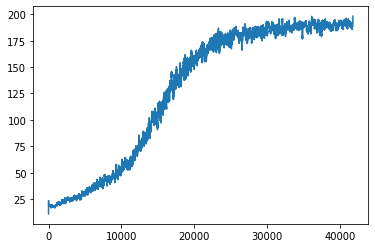

In [ ]:
plt.plot(plot_rewards)

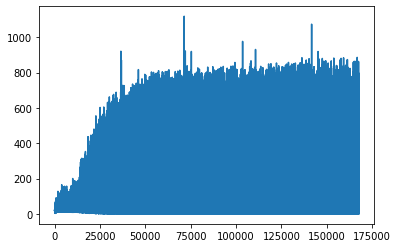

In [ ]:
plt.plot(plot_loss_value)

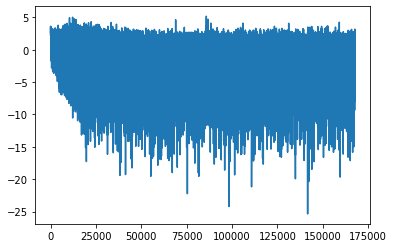

In [ ]:
plt.plot(plot_loss_act)

In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# To get smooth animations
import matplotlib.animation as animation
mpl.rc('animation', html='jshtml')

In [ ]:
def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

In [ ]:
!pip install gym[classic_control]

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.4 MB/s eta 0:00:00


In [ ]:
env.reset()
frame=[]
for step in range(300):
  states_v,action_t,ref_val=unpack_batch(batch,device=device)
  pred_action=net_act(states_v)
  action=torch.argmax(pred_action,1)
  for s in batch:
    state, reward, done, info = env.step(s.action)
    if done:
      break
    img = env.render(mode="rgb_array")
    frame.append(img)

plot_animation(frame,repeat=False)


/usr/local/lib/python3.9/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.9/dist-packages/gym/envs/classic_control/cartpole.py:179: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(
